1. Kết nối Drive và Giải nén file .zip

In [25]:
import os
import glob
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Xóa thư mục cũ và giải nén lại (đúng đường dẫn của bạn)
!rm -rf /content/vn30_data
!unzip -q /content/drive/MyDrive/SIC_AI_ForecastTrend/archive.zip -d /content/vn30_data/
print("Đã giải nén xong!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã giải nén xong!


2. Đọc và Gộp 30 file CSV thành một DataFrame

In [29]:
# 1. Đọc và gộp tất cả các file CSV
!pip install pandas_ta
import os
import glob
import pandas as pd
import numpy as np
import pandas_ta as ta

path = '/content/vn30_data/'
csv_files = glob.glob(path + "/**/*.csv", recursive=True)

df_list = []
for file in csv_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

rename_dict = {
    'time': 'TradingDate',
    'symbol': 'Symbol',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
}
df = df.rename(columns=rename_dict)

# Xóa cột 'Time' nếu còn tồn tại dư thừa
df = df.drop(columns=['Time'], errors='ignore')

# Chuyển đổi định dạng ngày tháng
try:
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
except:
    df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')

# Sắp xếp dữ liệu
df = df.sort_values(['Symbol', 'TradingDate']).reset_index(drop=True)

def add_advanced_indicators(df_group):
    # Đảm bảo các cột số liệu là kiểu float
    cols_to_fix = ['Close', 'Open', 'High', 'Low', 'Volume']
    for col in cols_to_fix:
        if col in df_group.columns:
            df_group[col] = pd.to_numeric(df_group[col], errors='coerce')

    # Momentum & Trend
    df_group['RSI_14'] = ta.rsi(df_group['Close'], length=14)
    df_group['EMA_20'] = ta.ema(df_group['Close'], length=20)
    df_group['EMA_50'] = ta.ema(df_group['Close'], length=50)

    # MACD
    macd = ta.macd(df_group['Close'])
    if macd is not None:
        df_group = pd.concat([df_group, macd], axis=1)

    # Volatility
    bb = ta.bbands(df_group['Close'], length=20)
    if bb is not None:
        df_group = pd.concat([df_group, bb], axis=1)

    # Return & Lag
    df_group['Return'] = df_group['Close'].pct_change()

    # Target: Xu hướng T+1
    df_group['Next_Close'] = df_group['Close'].shift(-1)
    df_group['Trend'] = (df_group['Next_Close'] > df_group['Close']).astype(int)

    return df_group

df = df.groupby('Symbol', group_keys=False).apply(add_advanced_indicators, include_groups=False)
df = df.dropna()

print("Dữ liệu sau khi chuẩn hóa tên cột và tính toán đặc trưng:", df.shape)
display(df.head())

Dữ liệu sau khi chuẩn hóa tên cột và tính toán đặc trưng: (43311, 20)


,TradingDate,Open,High,Low,Close,Volume,RSI_14,EMA_20,EMA_50,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,Return,Next_Close,Trend
49,2020-10-12,8.89,8.93,8.74,8.74,8642000,65.966359,8.475729,7.921000,0.272228,-0.000761,0.272989,7.865061,8.4575,9.049939,14.009795,0.738421,-0.009070,8.78,1
50,2020-10-13,8.78,8.78,8.67,8.78,5319900,66.939307,8.504707,7.954686,0.263633,-0.007485,0.271118,7.931050,8.4970,9.062950,13.321163,0.750022,0.004577,9.00,1
51,2020-10-14,8.82,9.04,8.78,9.00,20284500,71.726759,8.551878,7.995679,0.271444,0.000261,0.271183,8.002721,8.5495,9.096279,12.790902,0.911958,0.025057,9.19,1
52,2020-10-15,9.00,9.30,8.97,9.19,16334800,75.082664,8.612651,8.042515,0.289627,0.014755,0.274872,8.036531,8.6055,9.174469,13.223371,1.013649,0.021111,9.27,1
53,2020-10-16,9.19,9.38,9.08,9.27,8711000,76.355258,8.675256,8.090652,0.306954,0.025666,0.281288,8.063982,8.6620,9.260018,13.807845,1.008346,0.008705,9.49,1


3. Train

Tỷ lệ cân bằng thử nghiệm: 1.06
Đang huấn luyện mô hình với trọng số trung gian trên 24051 mẫu...

--- KẾT QUẢ DỰ BÁO CÂN BẰNG (ACCURACY & RECALL) ---
Accuracy: 0.6211
              precision    recall  f1-score   support

           0       0.72      0.78      0.75     13832
           1       0.27      0.21      0.23      5428

    accuracy                           0.62     19260
   macro avg       0.49      0.49      0.49     19260
weighted avg       0.59      0.62      0.60     19260



<Figure size 1000x800 with 0 Axes>

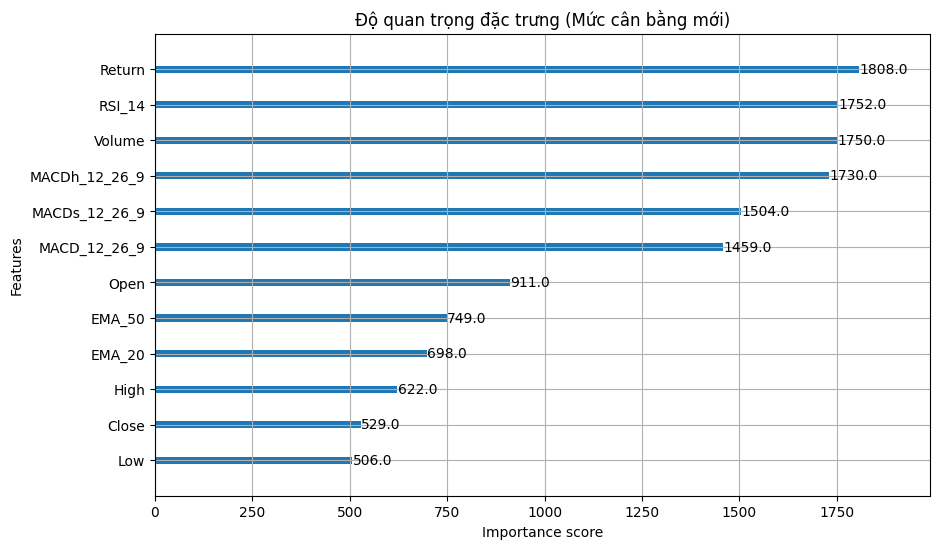

In [33]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'RSI_14', 'EMA_20', 'EMA_50',
    'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
    'BBL_20_2.0', 'BBM_20_2.0', 'BBU_20_2.0', 'Return'
]
available_features = [f for f in features if f in df.columns]

train_df = df[df['TradingDate'] < '2024-01-01'].copy()
test_df = df[df['TradingDate'] >= '2024-01-01'].copy()

X_train, y_train = train_df[available_features], train_df['Trend']
X_test, y_test = test_df[available_features], test_df['Trend']

count_0 = (y_train == 0).sum()
count_1 = (y_train == 1).sum()
weight_ratio_balanced = np.sqrt(count_0 / count_1)
print(f"Tỷ lệ cân bằng thử nghiệm: {weight_ratio_balanced:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=weight_ratio_balanced,
    random_state=42,
    eval_metric='logloss'
)

print(f"Đang huấn luyện mô hình với trọng số trung gian trên {len(X_train)} mẫu...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n--- KẾT QUẢ DỰ BÁO CÂN BẰNG (ACCURACY & RECALL) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15)
plt.title("Độ quan trọng đặc trưng (Mức cân bằng mới)")
plt.show()

In [34]:
import pickle
from google.colab import files

model_filename = 'xgboost_stock_model_v2.pkl'

model_data = {
    'model': model,
    'features': available_features,
    'accuracy': 0.6211,
    'recall_class_1': 0.21
}

with open(model_filename, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Đã lưu mô hình cân bằng vào file: {model_filename}")

files.download(model_filename)

Đã lưu mô hình cân bằng vào file: xgboost_stock_model_v2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 4. Hướng dẫn huấn luyện tiếp (Incremental Learning) với dữ liệu mới
Khi bạn có dữ liệu mới (ví dụ dữ liệu cuối năm 2024 hoặc 2025), bạn có thể cập nhật mô hình như sau:

In [ ]:
import pickle
import xgboost as xgb

def fine_tune_model(old_model_path, X_new, y_new):
    # Nạp mô hình cũ
    with open(old_model_path, 'rb') as f:
        data = pickle.load(f)
        old_model = data['model']
        features = data['features']

    print(f"Đang huấn luyện tiếp dựa trên mô hình: {old_model_path}")

    old_model.fit(X_new[features], y_new, xgb_model=old_model.get_booster())

    return old_model

print("Hàm fine_tune_model đã sẵn sàng. Khi có dữ liệu mới, bạn chỉ cần gọi hàm này.")